# Sea proximity

Distance from each grid cell to the nearest ocean coastline. Stored as `-distance_km` so higher values mean closer to water (livelier). Ocean cells are masked to `NaN` using `is_land` from `grid.nc`.

In [1]:
import geopandas as gpd
import numpy as np
import shapely
import xarray as xr
from shapely.strtree import STRtree

from common import RAW_DIR, load_grid, save_variable

VARIABLE = 'sea_proximity'
variable_raw = RAW_DIR / VARIABLE
variable_raw.mkdir(parents=True, exist_ok=True)

## 1. Fetch raw data

Natural Earth 1:10m **land polygons** (~8 MB). We derive coastlines from the polygon boundaries — the same dataset `regionmask` uses to build `is_land` in `02_grid` — so every island in the grid is guaranteed to have a matching coastline. Natural Earth's separate `ne_10m_coastline` shapefile silently omits small features (Karimata, parts of Antarctica, Admiralty Islands, …) that `ne_10m_land` includes, which was previously producing spuriously large distances for those island cells.

In [2]:
URL = 'https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip'
zip_path = variable_raw / 'ne_10m_land.zip'

if not zip_path.exists():
    print(f'downloading {URL}')
    from common import download
    await download(URL, zip_path)

print(f'{zip_path.name}: {zip_path.stat().st_size / 1024:.0f} KB')

ne_10m_land.zip: 3192 KB


## 2. Clean & transform

Reproject to Equal Earth (EPSG:8857) so planar distance in metres is a reasonable global approximation, then explode multi-part polygons to single-part before taking each polygon's boundary. Exploding first lets the STRtree index each island as its own feature — otherwise Eurasia's MultiPolygon bounding box would engulf half the map and defeat the spatial index.

In [3]:
land_polys = (
    gpd.read_file(zip_path)
    .to_crs('EPSG:8857')
    .explode(index_parts=False)
    .reset_index(drop=True)
)
coastlines = land_polys.boundary
print(f'{len(coastlines)} island/continent boundaries (reprojected to Equal Earth)')

6837 island/continent boundaries (reprojected to Equal Earth)


## 3. Interpolate onto the grid

For every land grid cell, find the nearest coastline segment via an STRtree query in Equal Earth coordinates, then invert (`-distance_km`) so higher = closer to water = better. Ocean cells are masked out.

In [4]:
grid = load_grid()

lat2d, lon2d = np.meshgrid(grid.lat.values, grid.lon.values, indexing='ij')
points = gpd.GeoSeries(
    gpd.points_from_xy(lon2d.ravel(), lat2d.ravel()),
    crs='EPSG:4326',
).to_crs('EPSG:8857')

tree = STRtree(coastlines.values)
nearest_idx = tree.nearest(points.values)
nearest_geoms = coastlines.values[nearest_idx]

distances_km = shapely.distance(np.asarray(points.values), nearest_geoms) / 1000

values = xr.DataArray(
    -distances_km.reshape(lat2d.shape),
    coords={'lat': grid.lat, 'lon': grid.lon},
    dims=('lat', 'lon'),
    name=VARIABLE,
).where(grid.is_land == 1)

## 4. Plot


<Axes: title={'center': 'sea_proximity'}, xlabel='longitude', ylabel='latitude'>

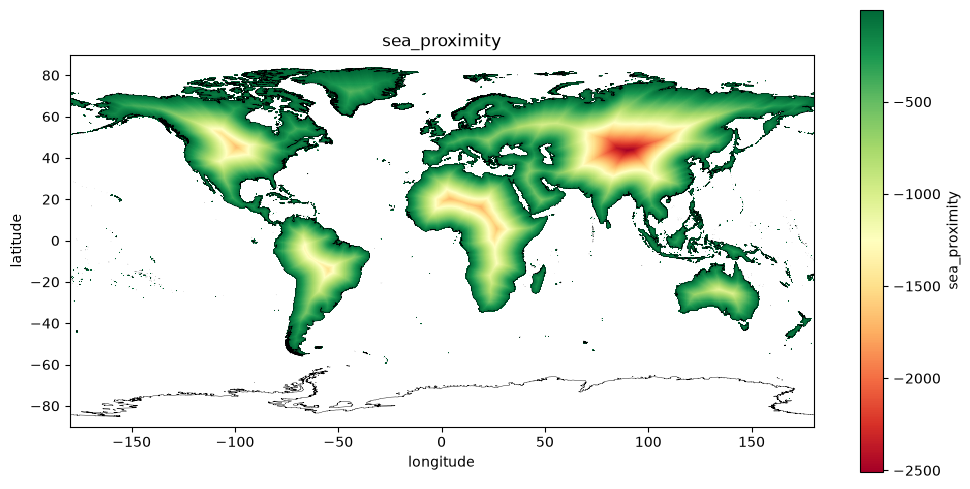

In [5]:
from common import plot_map
plot_map(values)

## 5. Save

In [6]:
out = save_variable(values, VARIABLE)
print(f'wrote {out}')

wrote /Users/lutz/Documents/alfatraining/projects/data-science-notebooks/data/world-livable-atlas/processed/sea_proximity.nc
